In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ─────────────────────────────────────────
#  STEP 1: CORPUS (VOCABULARY)
# ─────────────────────────────────────────

def preprocess(text):
    return text.lower().split()

def create_corpus(docs):
    processed_docs = [preprocess(doc) for doc in docs]
    vocabulary = sorted(set(
        word for doc in processed_docs
             for word in doc
    ))
    return processed_docs, vocabulary

In [3]:
# ─────────────────────────────────────────
#  STEP 2: TERM FREQUENCY (TF)
# ─────────────────────────────────────────

def compute_tf(word_list, vocabulary):
    word_count = {}
    for word in word_list:
        word_count[word] = word_count.get(word, 0) + 1
    tf_vector = np.array([
        word_count[w] / len(word_list) if w in word_count else 0
        for w in vocabulary
    ])
    return tf_vector

In [4]:
# ─────────────────────────────────────────
#  STEP 3: INVERSE DOCUMENT FREQUENCY (IDF)
# ─────────────────────────────────────────

def compute_idf(docs, vocabulary):
    N = len(docs)
    idf_vector = np.array([
        np.log((N + 1) / (1 + sum(1 for doc in docs if w in doc))) + 1
        for w in vocabulary
    ])
    return idf_vector

In [5]:
# ─────────────────────────────────────────
#  STEP 4: TF-IDF MATRIX
# ─────────────────────────────────────────

def compute_tf_idf(docs):
    processed_docs, vocabulary = create_corpus(docs)
    tf_matrix  = np.array([compute_tf(doc, vocabulary) for doc in processed_docs])
    idf_vector = compute_idf(processed_docs, vocabulary)
    return tf_matrix * idf_vector  # broadcasting: (4,V) * (V,) → (4,V)

In [6]:
# ─────────────────────────────────────────
#  STEP 5: COSINE SIMILARITY
# ─────────────────────────────────────────

def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / norm if norm != 0 else 0

In [7]:
# ─────────────────────────────────────────
#  STEP 6: PLAGIARISM CHECK (FULL MATRIX)
# ─────────────────────────────────────────

def check_plagiarism_all(docs):
    tf_idf = compute_tf_idf(docs)
    N = len(docs)
    sim = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            sim[i, j] = cosine_similarity(tf_idf[i], tf_idf[j])
    return sim

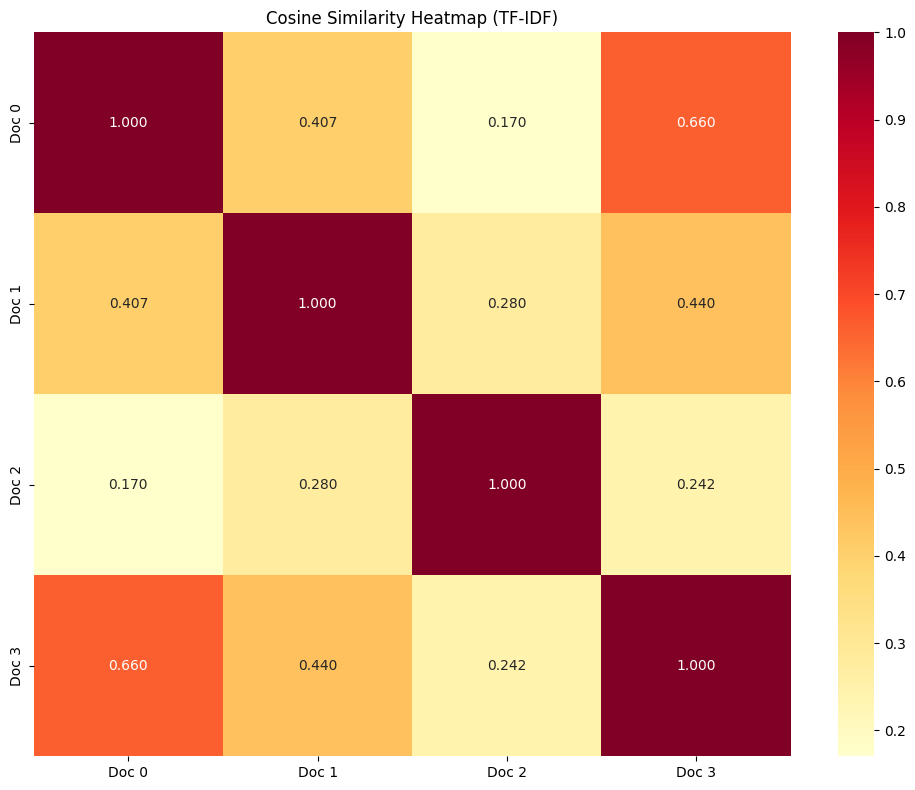

In [8]:
# ─────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────

docs = [
    "Học máy là một nhánh của trí tuệ nhân tạo",
    "Trí tuệ nhân tạo bao gồm học máy và mạng nơ ron",
    "Mạng nơ ron là một mô hình quan trọng trong học sâu",
    "Học sâu là một lĩnh vực của trí tuệ nhân tạo và học máy",
]

similarity_matrix = check_plagiarism_all(docs)

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,        # hiện số trong ô
    fmt=".3f",          # định dạng 3 chữ số thập phân
    cmap="YlOrRd",     # màu vàng → đỏ
    xticklabels=[f"Doc {i}" for i in range(4)],
    yticklabels=[f"Doc {i}" for i in range(4)],
)
plt.title("Cosine Similarity Heatmap (TF-IDF)")
plt.tight_layout()
plt.show()